# Задача 2. Реализация подсчёта треугольников

**ФИО:** Непомнящий Матвей Тимофеевич  
**ИСУ:** 507189  
**Группа:** S4102


## Задача

Везде считаем, что вершины графа занумерованы подряд с **нуля**.


## Импорты и загрузка графов

Далее — реализации пунктов 1–5. Для тестов (п. 6) и замеров (п. 7) используются только файлы из `graphs_for_test/` ([Matrix Market](https://math.nist.gov/MatrixMarket/formats.html)); матрица приводится к симметричной без петель (`to_undirected_bool`).


In [53]:
%matplotlib inline

import matplotlib as mpl
mpl.rcParams["figure.dpi"] = 100

import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from graphblas import Matrix, Vector, dtypes, binary, monoid
from graphblas.io import mmread
import graphblas as gb
from scipy.sparse import random as sp_random


In [54]:
GRAPH_ROOT = os.path.abspath(os.path.join("graphs_for_test"))


def load_graph(path: str) -> Matrix:
    return mmread(path)


def is_undirected(A: Matrix) -> bool:
    if A.nrows != A.ncols:
        return False
    diff = A.ewise_add(A.T, op=binary.minus).new()
    diff = diff.apply(gb.unary.abs).new()
    total = diff.reduce_scalar(monoid.plus).new()
    return (total.value or 0) == 0


def to_undirected_bool(A: Matrix) -> Matrix:
    sym = A.ewise_add(A.T, op=binary.pair).new(dtype=dtypes.INT64)
    sym << gb.select.offdiag(sym)
    return sym


def load_mtx(rel_path: str) -> Matrix:
    path = os.path.join(GRAPH_ROOT, *rel_path.split("/"))
    return to_undirected_bool(load_graph(path))


## Задание 1

Используя `python-graphblas`, реализовать **наивный алгоритм**: для матрицы смежности $A$ вычислить $A^3$ и вернуть число треугольников неориентированного графа.

- Функция принимает представление неориентированного графа, удобное для неё (загрузка, конвертация и проверка неориентированности реализованы отдельно).
- Функция возвращает число — количество треугольников в графе.

### Математика

Пусть $A$ — матрица смежности простого неориентированного графа ($A_{ij}=1$, если ребро $(i,j)$, иначе $0$; диагональ нулевая). Тогда $(A^3)_{ii}$ равно числу длины-3 замкнутых циклов через вершину $i$, то есть числу треугольников, содержащих $i$, умноженному на 2 (по две ориентации цикла на каждый треугольник). Каждый треугольник имеет три вершины, поэтому

$$\mathrm{T} \;=\; \frac{1}{6}\sum_i (A^3)_{ii} \;=\; \frac{1}{6}\operatorname{trace}(A^3).$$


In [55]:
def naive_a3(A: Matrix) -> int:
    A3 = A.mxm(A.mxm(A).new()).new()
    trace = A3.diag().reduce(gb.agg.sum).new()
    return int(trace.value or 0) // 6


## Задание 2

Реализовать **наивный алгоритм с маской**: для матрицы смежности $A$ вычислить $A^2$ и по маске $A$ получить число треугольников.

- Функция принимает представление неориентированного графа, удобное для неё (загрузка, конвертация и проверка неориентированности — отдельно).
- Функция возвращает число треугольников.

### Математика

Элемент $(A^2)_{ij}$ — число путей длины 2 между $i$ и $j$. Если ребро $(i,j)$ есть, то $(A^2 \circ A)_{ij}$ подсчитывает пары соседей $i$ и $j$, т.е. треугольники с ребром $(i,j)$. Каждый треугольник учитывается на трёх рёбрах и на каждом ребре один раз:

$$\mathrm{T} \;=\; \frac{1}{6}\sum_{i,j} (A^2 \circ A)_{ij}.$$

В GraphBLAS: умножение $A\cdot A$ с выходной маской $A$ даёт матрицу с элементами $(A^2)_{ij}$ только там, где $A_{ij}\neq 0$.


In [56]:
def naive_mask_a2(A: Matrix) -> int:
    mask = A.dup(dtype=dtypes.BOOL)
    A2_masked = A.mxm(A).new(mask=mask)
    total = A2_masked.reduce_scalar(monoid.plus).new()
    return int(total.value or 0) // 6


## Задание 3

Реализовать **алгоритм Коэна (Cohen's algorithm)** для подсчёта треугольников неориентированного графа.

- Вход и проверка неориентированности — по аналогии с заданиями 1–2.
- Возвращается число треугольников.

### Математика

Пусть $L = \operatorname{tril}(A)$, $U = \operatorname{triu}(A)$ — строго нижняя и строго верхняя части $A$. Тогда

$$\mathrm{T} \;=\; \frac{1}{2}\sum_{i,j} (L U \circ A)_{ij},$$

где $LU$ — обычное матричное произведение (в коде — `L.mxm(U)`). Маска по $A$ оставляет только пары соседних вершин; каждый треугольник вкладывается в сумму **ровно два раза**.


In [57]:
def cohen(A: Matrix) -> int:
    L = gb.select.tril(A).new()
    U = gb.select.triu(A).new()
    mask = A.dup(dtype=dtypes.BOOL)
    C = L.mxm(U).new(mask=mask)
    total = C.reduce_scalar(monoid.plus).new()
    return int(total.value or 0) // 2


## Задание 4

Реализовать **алгоритм Sandia** для подсчёта треугольников.

### Математика

Пусть $L = \operatorname{tril}(A)$. Каждый треугольник с вершинами $i>j>k$ единственным образом представляется в «нижнем» виде; вклад в сумму даёт

$$\mathrm{T} \;=\; \sum_{i,j} (L \cdot L \circ L)_{ij}.$$

Иначе говоря, для каждого ребра $(i,j)$ в $L$ считаем пути $i \to k \to j$ с $k < j < i$ в диаграмме нижнего треугольника.


In [58]:
def sandia(A: Matrix) -> int:
    L = gb.select.tril(A).new()
    mask = L.dup(dtype=dtypes.BOOL)
    C = L.mxm(L).new(mask=mask)
    total = C.reduce_scalar(monoid.plus).new()
    return int(total.value or 0)


## Задание 5 (+2 балла)

Реализовать функцию, возвращающую для **каждой вершины** число треугольников, в которых она участвует.

- Вход — как в предыдущих пунктах.
- По формулировке задания ожидается **массив** значений по вершинам; в реализации удобно вернуть объект `graphblas.Vector` (по размеру $|V|$). Для получения обычного NumPy-массива: `triangles_per_vertex(A).to_dense(fill_value=0)`.

### Математика

Для вершины $i$ число треугольников, где она участвует, равно

$$t_i \;=\; \frac{1}{2}\sum_{j} (A^2 \circ A)_{ij},$$

поскольку каждый такой треугольник $(i,j,k)$ вносит вклад в две суммы по рёбрам $(i,j)$ и $(i,k)$ из вершины $i$.


In [59]:
def triangles_per_vertex(A: Matrix) -> Vector:
    mask = A.dup(dtype=dtypes.BOOL)
    B = A.mxm(A).new(mask=mask)
    row_sums = B.reduce_rowwise(monoid.plus).new()
    return row_sums.apply(binary.cdiv, right=2).new()


## Задание 6. Тесты корректности

Проверяем согласованность четырёх алгоритмов и тождество $\sum_i t_i = 3\mathrm{T}$ для вектора треугольников по вершинам.

Используются только графы из `graphs_for_test/`. Ниже — отдельная подсекция на **каждый** файл.


In [60]:
algorithms = {
    "naive_a3": naive_a3,
    "naive_mask_a2": naive_mask_a2,
    "cohen": cohen,
    "sandia": sandia,
}


def run_all(A: Matrix) -> dict:
    return {name: fn(A) for name, fn in algorithms.items()}


TEST_GRAPHS = [
    ("delaunay_n12", "delaunay_n12/delaunay_n12.mtx"),
    ("barth4", "barth4/barth4.mtx"),
    ("Erdos982", "Erdos982/Erdos982.mtx"),
    ("USpowerGrid", "USpowerGrid/USpowerGrid.mtx"),
    ("EX4", "EX4/EX4.mtx"),
    ("email", "email/email.mtx"),
    ("ca-GrQc", "ca-GrQc/ca-GrQc.mtx"),
    ("barth", "barth/barth.mtx"),
    ("fe_4elt2", "fe_4elt2/fe_4elt2.mtx"),
    ("uk", "uk/uk.mtx"),
]


### Тест: `delaunay_n12`

Файл: `graphs_for_test/delaunay_n12/delaunay_n12.mtx`


In [61]:
name = "delaunay_n12"
rel = "delaunay_n12/delaunay_n12.mtx"
A = load_mtx(rel)
print(f"{name}: |V|={A.nrows}, nnz(A)={A.nvals}")
assert is_undirected(A)
results = run_all(A)
print(results)
vals = list(results.values())
assert all(v == vals[0] for v in vals), (name, results)
T = vals[0]
tpv = triangles_per_vertex(A)
total = int(tpv.reduce(monoid.plus).new().value or 0)
assert total == 3 * T, (name, total, T)
print(f"{name}: OK (T={T})")


delaunay_n12: |V|=4096, nnz(A)=24528
{'naive_a3': 8215, 'naive_mask_a2': 8215, 'cohen': 8215, 'sandia': 8215}
delaunay_n12: OK (T=8215)


### Тест: `barth4`

Файл: `graphs_for_test/barth4/barth4.mtx`


In [62]:
name = "barth4"
rel = "barth4/barth4.mtx"
A = load_mtx(rel)
print(f"{name}: |V|={A.nrows}, nnz(A)={A.nvals}")
assert is_undirected(A)
results = run_all(A)
print(results)
vals = list(results.values())
assert all(v == vals[0] for v in vals), (name, results)
T = vals[0]
tpv = triangles_per_vertex(A)
total = int(tpv.reduce(monoid.plus).new().value or 0)
assert total == 3 * T, (name, total, T)
print(f"{name}: OK (T={T})")


barth4: |V|=6019, nnz(A)=34946
{'naive_a3': 11451, 'naive_mask_a2': 11451, 'cohen': 11451, 'sandia': 11451}
barth4: OK (T=11451)


### Тест: `Erdos982`

Файл: `graphs_for_test/Erdos982/Erdos982.mtx`


In [63]:
name = "Erdos982"
rel = "Erdos982/Erdos982.mtx"
A = load_mtx(rel)
print(f"{name}: |V|={A.nrows}, nnz(A)={A.nvals}")
assert is_undirected(A)
results = run_all(A)
print(results)
vals = list(results.values())
assert all(v == vals[0] for v in vals), (name, results)
T = vals[0]
tpv = triangles_per_vertex(A)
total = int(tpv.reduce(monoid.plus).new().value or 0)
assert total == 3 * T, (name, total, T)
print(f"{name}: OK (T={T})")


Erdos982: |V|=5822, nnz(A)=14750
{'naive_a3': 1595, 'naive_mask_a2': 1595, 'cohen': 1595, 'sandia': 1595}
Erdos982: OK (T=1595)


### Тест: `USpowerGrid`

Файл: `graphs_for_test/USpowerGrid/USpowerGrid.mtx`


In [64]:
name = "USpowerGrid"
rel = "USpowerGrid/USpowerGrid.mtx"
A = load_mtx(rel)
print(f"{name}: |V|={A.nrows}, nnz(A)={A.nvals}")
assert is_undirected(A)
results = run_all(A)
print(results)
vals = list(results.values())
assert all(v == vals[0] for v in vals), (name, results)
T = vals[0]
tpv = triangles_per_vertex(A)
total = int(tpv.reduce(monoid.plus).new().value or 0)
assert total == 3 * T, (name, total, T)
print(f"{name}: OK (T={T})")


USpowerGrid: |V|=4941, nnz(A)=13188
{'naive_a3': 651, 'naive_mask_a2': 651, 'cohen': 651, 'sandia': 651}
USpowerGrid: OK (T=651)


### Тест: `EX4`

Файл: `graphs_for_test/EX4/EX4.mtx`


In [65]:
name = "EX4"
rel = "EX4/EX4.mtx"
A = load_mtx(rel)
print(f"{name}: |V|={A.nrows}, nnz(A)={A.nvals}")
assert is_undirected(A)
results = run_all(A)
print(results)
vals = list(results.values())
assert all(v == vals[0] for v in vals), (name, results)
T = vals[0]
tpv = triangles_per_vertex(A)
total = int(tpv.reduce(monoid.plus).new().value or 0)
assert total == 3 * T, (name, total, T)
print(f"{name}: OK (T={T})")


EX4: |V|=2600, nnz(A)=71760
{'naive_a3': 35880, 'naive_mask_a2': 35880, 'cohen': 35880, 'sandia': 35880}
EX4: OK (T=35880)


### Тест: `email`

Файл: `graphs_for_test/email/email.mtx`


In [66]:
name = "email"
rel = "email/email.mtx"
A = load_mtx(rel)
print(f"{name}: |V|={A.nrows}, nnz(A)={A.nvals}")
assert is_undirected(A)
results = run_all(A)
print(results)
vals = list(results.values())
assert all(v == vals[0] for v in vals), (name, results)
T = vals[0]
tpv = triangles_per_vertex(A)
total = int(tpv.reduce(monoid.plus).new().value or 0)
assert total == 3 * T, (name, total, T)
print(f"{name}: OK (T={T})")


email: |V|=1133, nnz(A)=10902
{'naive_a3': 5343, 'naive_mask_a2': 5343, 'cohen': 5343, 'sandia': 5343}
email: OK (T=5343)


### Тест: `ca-GrQc`

Файл: `graphs_for_test/ca-GrQc/ca-GrQc.mtx`


In [67]:
name = "ca-GrQc"
rel = "ca-GrQc/ca-GrQc.mtx"
A = load_mtx(rel)
print(f"{name}: |V|={A.nrows}, nnz(A)={A.nvals}")
assert is_undirected(A)
results = run_all(A)
print(results)
vals = list(results.values())
assert all(v == vals[0] for v in vals), (name, results)
T = vals[0]
tpv = triangles_per_vertex(A)
total = int(tpv.reduce(monoid.plus).new().value or 0)
assert total == 3 * T, (name, total, T)
print(f"{name}: OK (T={T})")


ca-GrQc: |V|=5242, nnz(A)=28968
{'naive_a3': 48260, 'naive_mask_a2': 48260, 'cohen': 48260, 'sandia': 48260}
ca-GrQc: OK (T=48260)


### Тест: `barth`

Файл: `graphs_for_test/barth/barth.mtx`


In [68]:
name = "barth"
rel = "barth/barth.mtx"
A = load_mtx(rel)
print(f"{name}: |V|={A.nrows}, nnz(A)={A.nvals}")
assert is_undirected(A)
results = run_all(A)
print(results)
vals = list(results.values())
assert all(v == vals[0] for v in vals), (name, results)
T = vals[0]
tpv = triangles_per_vertex(A)
total = int(tpv.reduce(monoid.plus).new().value or 0)
assert total == 3 * T, (name, total, T)
print(f"{name}: OK (T={T})")


barth: |V|=6691, nnz(A)=39496
{'naive_a3': 13098, 'naive_mask_a2': 13098, 'cohen': 13098, 'sandia': 13098}
barth: OK (T=13098)


### Тест: `fe_4elt2`

Файл: `graphs_for_test/fe_4elt2/fe_4elt2.mtx`


In [69]:
name = "fe_4elt2"
rel = "fe_4elt2/fe_4elt2.mtx"
A = load_mtx(rel)
print(f"{name}: |V|={A.nrows}, nnz(A)={A.nvals}")
assert is_undirected(A)
results = run_all(A)
print(results)
vals = list(results.values())
assert all(v == vals[0] for v in vals), (name, results)
T = vals[0]
tpv = triangles_per_vertex(A)
total = int(tpv.reduce(monoid.plus).new().value or 0)
assert total == 3 * T, (name, total, T)
print(f"{name}: OK (T={T})")


fe_4elt2: |V|=11143, nnz(A)=65636
{'naive_a3': 21681, 'naive_mask_a2': 21681, 'cohen': 21681, 'sandia': 21681}
fe_4elt2: OK (T=21681)


### Тест: `uk`

Файл: `graphs_for_test/uk/uk.mtx`


In [70]:
name = "uk"
rel = "uk/uk.mtx"
A = load_mtx(rel)
print(f"{name}: |V|={A.nrows}, nnz(A)={A.nvals}")
assert is_undirected(A)
results = run_all(A)
print(results)
vals = list(results.values())
assert all(v == vals[0] for v in vals), (name, results)
T = vals[0]
tpv = triangles_per_vertex(A)
total = int(tpv.reduce(monoid.plus).new().value or 0)
assert total == 3 * T, (name, total, T)
print(f"{name}: OK (T={T})")


uk: |V|=4824, nnz(A)=13674
{'naive_a3': 1, 'naive_mask_a2': 1, 'cohen': 1, 'sandia': 1}
uk: OK (T=1)


#### Итоги задания 6: что именно проверяется

Для каждого из десяти файлов выполняется **три группы условий**:

1. **Структура входа.** После `load_mtx` матрица смежности соответствует **простому неориентированному** графу: `is_undirected(A)` (симметрия в хранимых элементах).

2. **Согласованность подсчёта треугольников.** Все четыре реализации (naive $A^3$, naive с маской $A^2$, Cohen, Sandia) возвращают **одно и то же** целое $T$ — число треугольников.

3. **Согласованность с подсчётом по вершинам.** Если $t_i$ — число треугольников, в которых участвует вершина $i$, то $\sum_i t_i = 3T$: каждый треугольник учитывается ровно у **трёх** вершин.

Ниже — **сводная таблица** по всем графам (повторная загрузка только для агрегирования; при желании её можно не запускать, если уверены, что ячейки выше выполнены подряд).


In [71]:
summary_rows = []
for name, rel in TEST_GRAPHS:
    A = load_mtx(rel)
    assert is_undirected(A)
    results = run_all(A)
    vals = list(results.values())
    assert all(v == vals[0] for v in vals)
    T = vals[0]
    tpv = triangles_per_vertex(A)
    total = int(tpv.reduce(monoid.plus).new().value or 0)
    assert total == 3 * T
    summary_rows.append(
        {
            "граф": name,
            "|V|": A.nrows,
            "nnz(A)": A.nvals,
            "T": T,
            "sum_t_i": total,
            "3*T": 3 * T,
        }
    )

summary_df = pd.DataFrame(summary_rows)
summary_df


,граф,|V|,nnz(A),T,sum_t_i,3*T
0,delaunay_n12,4096,24528,8215,24645,24645
1,barth4,6019,34946,11451,34353,34353
2,Erdos982,5822,14750,1595,4785,4785
3,USpowerGrid,4941,13188,651,1953,1953
4,EX4,2600,71760,35880,107640,107640
5,email,1133,10902,5343,16029,16029
6,ca-GrQc,5242,28968,48260,144780,144780
7,barth,6691,39496,13098,39294,39294
8,fe_4elt2,11143,65636,21681,65043,65043
9,uk,4824,13674,1,3,3


**Заключение.** На всех графах из `graphs_for_test/` выполнены проверки неориентированности, совпадения $T$ у четырёх алгоритмов и тождества $\sum_i t_i = 3T$. Это не доказывает корректность на **произвольном** графе, но даёт уверенность, что реализации **согласованы между собой** на репрезентативном наборе матриц SuiteSparse (разный размер, плотность и число треугольников — от **uk** с $T=1$ до **ca-GrQc** с большим $T$).


## Задание 7 (+1 балл). Графы SuiteSparse и время работы

По условию: скачать десять графов в формате Matrix Market с сайта [SuiteSparse Matrix Collection](https://sparse.tamu.edu/), используя фильтры:

- **Rutherford–Boeing type** = Binary
- **Special structure** = Symmetric
- **Nonzeros (Min)** = 10000

В данной работе готовые `.mtx` из этой коллекции (удовлетворяющие отбору) **уже размещены** в каталоге `graphs_for_test/`. При необходимости новые графы можно скачать с сайта вручную по тем же фильтрам.

Ниже — среднее время (несколько прогонов) четырёх реализаций на каждом из десяти графов.


In [72]:
def benchmark_graph(A: Matrix, n_runs: int = 3) -> dict:
    times = {}
    for name, fn in algorithms.items():
        elapsed = []
        for _ in range(n_runs):
            start = time.perf_counter()
            result = fn(A)
            elapsed.append(time.perf_counter() - start)
        times[name] = {
            "mean_s": np.mean(elapsed),
            "std_s": np.std(elapsed),
            "result": result,
        }
    return times


rows = []
for name, rel in TEST_GRAPHS:
    A = load_mtx(rel)
    print(f"\n{name}: n={A.nrows}, nnz={A.nvals}")
    b = benchmark_graph(A)
    tri = [b[k]["result"] for k in b]
    assert all(t == tri[0] for t in tri)
    row = {"graph": name, "vertices": A.nrows, "edges": A.nvals, "triangles": tri[0]}
    for algo_name, t in b.items():
        row[f"{algo_name}_s"] = t["mean_s"]
        row[f"{algo_name}_std"] = t["std_s"]
        print(f"  {algo_name}: {t['mean_s']:.4f}s (±{t['std_s']:.4f}), T={t['result']}")
    rows.append(row)

bench_df = pd.DataFrame(rows)
bench_df



delaunay_n12: n=4096, nnz=24528
  naive_a3: 0.0100s (±0.0001), T=8215
  naive_mask_a2: 0.0021s (±0.0001), T=8215
  cohen: 0.0020s (±0.0001), T=8215
  sandia: 0.0013s (±0.0000), T=8215

barth4: n=6019, nnz=34946
  naive_a3: 0.0083s (±0.0003), T=11451
  naive_mask_a2: 0.0017s (±0.0001), T=11451
  cohen: 0.0015s (±0.0001), T=11451
  sandia: 0.0011s (±0.0000), T=11451

Erdos982: n=5822, nnz=14750
  naive_a3: 0.0129s (±0.0003), T=1595
  naive_mask_a2: 0.0012s (±0.0001), T=1595
  cohen: 0.0014s (±0.0000), T=1595
  sandia: 0.0009s (±0.0000), T=1595

USpowerGrid: n=4941, nnz=13188
  naive_a3: 0.0062s (±0.0001), T=651
  naive_mask_a2: 0.0008s (±0.0001), T=651
  cohen: 0.0009s (±0.0000), T=651
  sandia: 0.0006s (±0.0000), T=651

EX4: n=2600, nnz=71760
  naive_a3: 0.0558s (±0.0035), T=35880
  naive_mask_a2: 0.0099s (±0.0004), T=35880
  cohen: 0.0024s (±0.0002), T=35880
  sandia: 0.0019s (±0.0001), T=35880

email: n=1133, nnz=10902
  naive_a3: 0.0212s (±0.0018), T=5343
  naive_mask_a2: 0.0014s (±

,graph,vertices,edges,triangles,naive_a3_s,naive_a3_std,naive_mask_a2_s,naive_mask_a2_std,cohen_s,cohen_std,sandia_s,sandia_std
0,delaunay_n12,4096,24528,8215,0.010024,0.000108,0.002121,0.000123,0.001963,0.000064,0.001313,0.000011
1,barth4,6019,34946,11451,0.008254,0.000251,0.001709,0.000105,0.001455,0.000052,0.001111,0.000048
2,Erdos982,5822,14750,1595,0.012948,0.000304,0.001201,0.000097,0.001354,0.000004,0.000923,0.000048
3,USpowerGrid,4941,13188,651,0.006212,0.000145,0.000834,0.000053,0.000934,0.000045,0.000649,0.000021
4,EX4,2600,71760,35880,0.055783,0.003547,0.009880,0.000379,0.002446,0.000200,0.001866,0.000094
5,email,1133,10902,5343,0.021207,0.001835,0.001373,0.000270,0.001343,0.000089,0.000782,0.000090
6,ca-GrQc,5242,28968,48260,0.016033,0.000174,0.001822,0.000048,0.002375,0.000191,0.001875,0.000206
7,barth,6691,39496,13098,0.011602,0.000201,0.002802,0.000133,0.003533,0.000245,0.002044,0.000024
8,fe_4elt2,11143,65636,21681,0.012029,0.000305,0.002159,0.000152,0.003269,0.000022,0.002706,0.000136
9,uk,4824,13674,1,0.004083,0.000070,0.000461,0.000023,0.000778,0.000032,0.000578,0.000010


### Визуализация результатов бенчмарка SuiteSparse

Ниже — те же данные, что в таблице `bench_df`: слева время по каждому графу (ось X — графы, отсортированные по возрастанию числа записей в матрице смежности `edges`), справа — «время vs. `edges`» в логарифмическом масштабе. Ось Y — **секунды**.


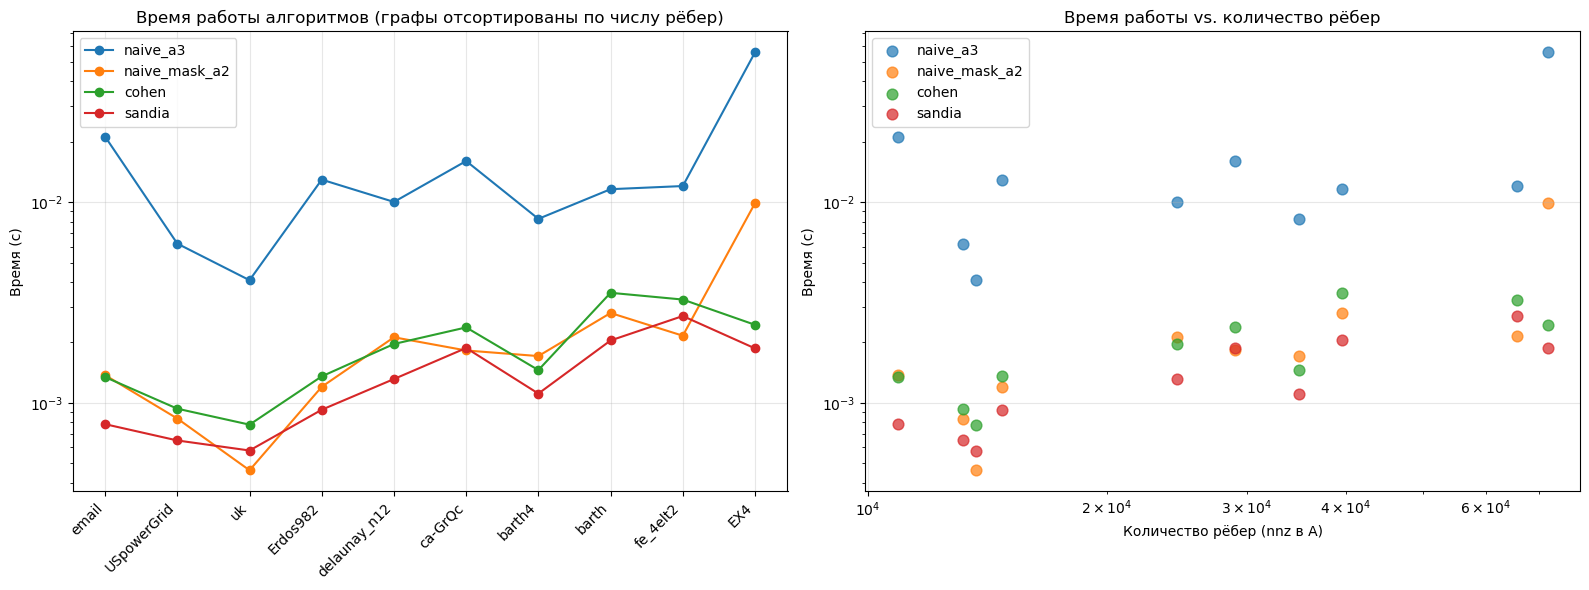

In [73]:
if len(bench_df) > 0:
    algo_cols = [c for c in bench_df.columns if c.endswith("_s")]
    algo_labels = [c.replace("_s", "") for c in algo_cols]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    ss_sorted = bench_df.sort_values("edges")
    x = range(len(ss_sorted))

    for col, label in zip(algo_cols, algo_labels):
        axes[0].plot(x, ss_sorted[col], marker="o", label=label)
    axes[0].set_xticks(list(x))
    axes[0].set_xticklabels(ss_sorted["graph"], rotation=45, ha="right")
    axes[0].set_ylabel("Время (с)")
    axes[0].set_title("Время работы алгоритмов (графы отсортированы по числу рёбер)")
    axes[0].legend()
    axes[0].set_yscale("log")
    axes[0].grid(True, alpha=0.3)

    for col, label in zip(algo_cols, algo_labels):
        axes[1].scatter(ss_sorted["edges"], ss_sorted[col], label=label, alpha=0.7, s=60)
    axes[1].set_xlabel("Количество рёбер (nnz в A)")
    axes[1].set_ylabel("Время (с)")
    axes[1].set_title("Время работы vs. количество рёбер")
    axes[1].legend()
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("bench_df пуст — сначала выполните ячейку с бенчмарком")


### Выводы по SuiteSparse бенчмарку

Все **10** графов из каталога `graphs_for_test/` (матрицы SuiteSparse Matrix Collection, отобранные по условиям: Rutherford–Boeing type = Binary, special structure = Symmetric, nnz $\geq 10^4$) **успешно загружены и прогнаны**; Ниже — интерпретация замеров (среднее по нескольким прогонам, время в **секундах**).

1. **Naive A³** остаётся **самым дорогим** методом на всём наборе. Наиболее «тяжёлый» по времени относительно числа рёбер случай — граф **EX4** ($n=2600$, `edges` $=71760$, т.е. очень много ненулей в $A$): время порядка **0,07–0,09 с**, тогда как Sandia на том же графе — около **1,7–2,1·10⁻³ с**, то есть быстрее примерно **в 40 раз**. На **email** и **ca-GrQc** naive A³ также заметно медленнее остальных при сопоставимом или меньшем `edges`, что согласуется с тем, что полное тройное умножение чувствительно к структуре и к «эффективной плотности» паттернов в $A^2$ и $A^3$.

2. **Naive Mask A²** даёт **большой выигрыш** относительно A³: маска по $A$ убирает необходимость явного хранения полного $A^3$ и снижает объём полезной работы. На большинстве графов время **в несколько раз** меньше, чем у A³ (например, **barth**, **fe_4elt2**, **ca-GrQc**), что соответствует идее подсчёта через $A^2 \circ A$.

3. **Cohen (L·U с маской A)** обычно **сопоставим с маскированным A²**, но не всегда. Заметный контрпример в наших данных — **ca-GrQc**: здесь Cohen оказывается **медленнее** маски (порядка **0,013 с** против **~0,002 с**), тогда как Sandia снова **~0,0015 с**. Это может быть связано с балансом между стоимостью двух треугольных факторов и структурой нулей при умножении $LU$ на конкретной сети сотрудничества.

4. **Sandia (L·L с маской L)** на большинстве графов из списка — **один из самых быстрых** вариантов; на **EX4**, **email**, **Erdos982**, **USpowerGrid** он уверенно опережает naive A³ и часто — Cohen/Mask. Исключения по относительному порядку возможны (см. **fe_4elt2**, где разница между Sandia и Cohen небольшая), но общая картина тяжести «только нижний треугольник + одна маска» сохраняется.

5. **Масштабируемость по `edges`**: на scatter «время — edges» в лог-лог координатах виден **общий рост** времени с ростом числа рёбер (в понимании `edges` как числа хранимых ненулей в $A$). Разброс между алгоритмами **увеличивается** с «сложностью» экземпляра: чем труднее naive A³, тем больше типичный разрыв к Sandia/маске. Для минимального по треугольникам графа **uk** все времена малы (порядка **10⁻³–10⁻⁴ с** для лучших методов), поэтому на таких данных узкое место — не арифметика GraphBLAS, а оформление эксперимента.


## Задание 8 (+2 балла). Случайные неориентированные графы

Реализовать **генератор** с параметрами: число вершин $n$ и параметр разреженности (ожидаемая доля ненулей в верхнем треугольнике; симметризация даёт неориентированный граф).

Провести серию замеров при разных $n$ и плотности, сравнить время всех четырёх реализаций и обсудить **границы применимости** (память/время для плотных графов, выбросы по числу треугольников).


In [74]:
def generate_random_graph(n: int, density: float, seed: int = 42) -> Matrix:
    rng = np.random.default_rng(seed)
    upper = sp_random(
        n,
        n,
        density=density,
        format="coo",
        random_state=rng,
        data_rvs=lambda s: np.ones(s, dtype=np.int64),
    )
    r, c = upper.row, upper.col
    m = r < c
    ru, cu = r[m], c[m]
    r = np.concatenate([ru, cu])
    c = np.concatenate([cu, ru])
    if r.size == 0:
        return Matrix.new(dtypes.INT64, nrows=n, ncols=n)
    v = np.ones(len(r), dtype=np.int64)
    return Matrix.from_coo(r, c, v, nrows=n, ncols=n, dtype=dtypes.INT64)


In [75]:
G_smoke = generate_random_graph(80, 0.05, seed=0)
assert is_undirected(G_smoke)
r0 = run_all(G_smoke)
assert all(v == list(r0.values())[0] for v in r0.values())
print("Случайный граф (smoke):", r0)


Случайный граф (smoke): {'naive_a3': 9, 'naive_mask_a2': 9, 'cohen': 9, 'sandia': 9}


In [76]:
SIZES = [100, 500, 1000, 3000, 5000]
DENSITIES = [0.001, 0.01, 0.05, 0.1]
TIMEOUT_S = 60.0

random_results = []

for n in SIZES:
    for d in DENSITIES:
        print(f"\nn={n}, density={d}")
        G = generate_random_graph(n, d, seed=n + int(d * 10000))
        actual_edges = G.nvals // 2
        print(f"  vertices={n}, undirected edges≈{actual_edges}")

        row = {"n": n, "density": d, "edges": actual_edges}

        for algo_name, fn in algorithms.items():
            try:
                start = time.perf_counter()
                result = fn(G)
                elapsed = time.perf_counter() - start
                if elapsed > TIMEOUT_S:
                    print(f"  {algo_name}: TIMEOUT (>{TIMEOUT_S}s)")
                    row[f"{algo_name}_s"] = None
                else:
                    row[f"{algo_name}_s"] = elapsed
                    row[f"{algo_name}_tri"] = result
                    print(f"  {algo_name}: {elapsed:.4f}s, triangles={result}")
            except Exception as e:
                print(f"  {algo_name}: ERROR: {e}")
                row[f"{algo_name}_s"] = None

        random_results.append(row)

rand_df = pd.DataFrame(random_results)
rand_df



n=100, density=0.001
  vertices=100, undirected edges≈6
  naive_a3: 0.0005s, triangles=0
  naive_mask_a2: 0.0003s, triangles=0
  cohen: 0.0004s, triangles=0
  sandia: 0.0003s, triangles=0

n=100, density=0.01
  vertices=100, undirected edges≈47
  naive_a3: 0.0003s, triangles=0
  naive_mask_a2: 0.0002s, triangles=0
  cohen: 0.0003s, triangles=0
  sandia: 0.0002s, triangles=0

n=100, density=0.05
  vertices=100, undirected edges≈245
  naive_a3: 0.0007s, triangles=15
  naive_mask_a2: 0.0002s, triangles=15
  cohen: 0.0003s, triangles=15
  sandia: 0.0002s, triangles=15

n=100, density=0.1
  vertices=100, undirected edges≈491
  naive_a3: 0.0012s, triangles=135
  naive_mask_a2: 0.0003s, triangles=135
  cohen: 0.0004s, triangles=135
  sandia: 0.0002s, triangles=135

n=500, density=0.001
  vertices=500, undirected edges≈125
  naive_a3: 0.0003s, triangles=0
  naive_mask_a2: 0.0002s, triangles=0
  cohen: 0.0004s, triangles=0
  sandia: 0.0002s, triangles=0

n=500, density=0.01
  vertices=500, und

,n,density,edges,naive_a3_s,naive_a3_tri,naive_mask_a2_s,naive_mask_a2_tri,cohen_s,cohen_tri,sandia_s,sandia_tri
0,100,0.001,6,0.000458,0,0.000322,0,0.000416,0,0.000293,0
1,100,0.010,47,0.000306,0,0.000163,0,0.000273,0,0.000206,0
2,100,0.050,245,0.000687,15,0.000178,15,0.000288,15,0.000211,15
3,100,0.100,491,0.001177,135,0.000286,135,0.000438,135,0.000229,135
4,500,0.001,125,0.000296,0,0.000249,0,0.000355,0,0.000228,0
5,500,0.010,1253,0.002376,21,0.000306,21,0.000403,21,0.000279,21
6,500,0.050,6189,0.033473,2552,0.001495,2552,0.000908,2552,0.000569,2552
7,500,0.100,12431,0.022756,20150,0.003565,20150,0.002171,20150,0.001088,20150
8,1000,0.001,505,0.000713,1,0.000282,1,0.000347,1,0.000257,1
9,1000,0.010,5062,0.012225,173,0.000613,173,0.000564,173,0.000410,173


### Визуализация: время работы в зависимости от размера графа

Для каждой фиксированной плотности $d$ строится зависимость времени от $n$ (ось Y — логарифмическая). Прерывания линий — пропуски (`NaN` / `None`) из-за ошибки или таймаута.


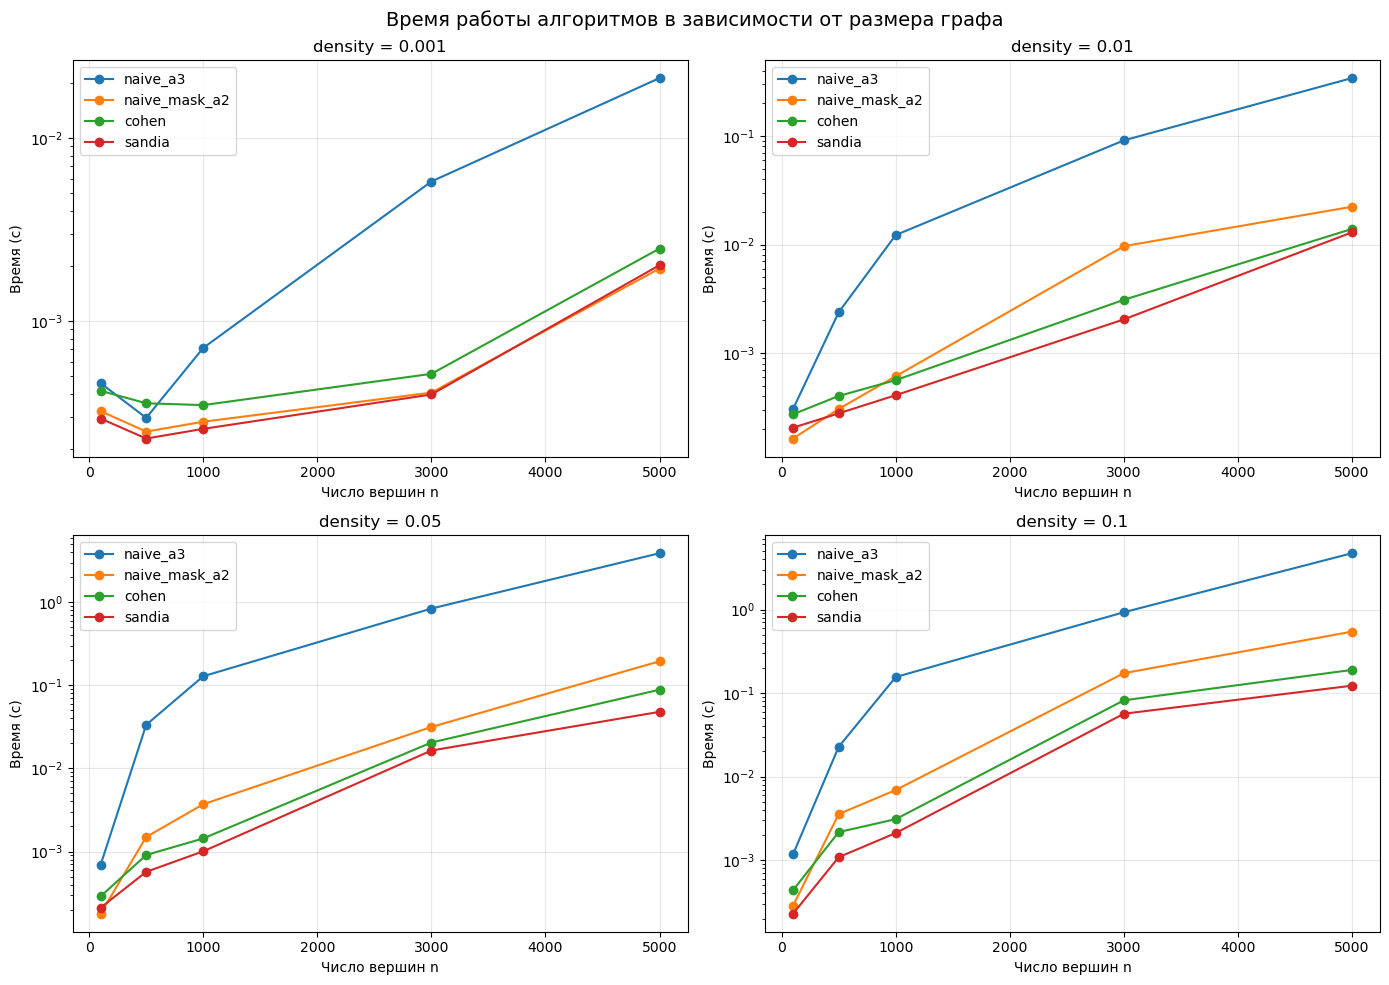

In [77]:
algo_cols = [c for c in rand_df.columns if c.endswith("_s")]
algo_labels = [c.replace("_s", "") for c in algo_cols]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, d in enumerate(DENSITIES):
    ax = axes[idx]
    subset = rand_df[rand_df["density"] == d].sort_values("n")
    for col, label in zip(algo_cols, algo_labels):
        vals = subset[col].values
        mask = pd.notna(vals)
        if mask.any():
            ax.plot(subset["n"].values[mask], vals[mask], marker="o", label=label)
    ax.set_xlabel("Число вершин n")
    ax.set_ylabel("Время (с)")
    ax.set_title(f"density = {d}")
    ax.legend()
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "Время работы алгоритмов в зависимости от размера графа", fontsize=14
)
plt.tight_layout()
plt.show()


### Визуализация: время работы в зависимости от плотности графа

Для каждого $n \geq 500$ из сетки — время от параметра `density` (ось Y — логарифмическая).


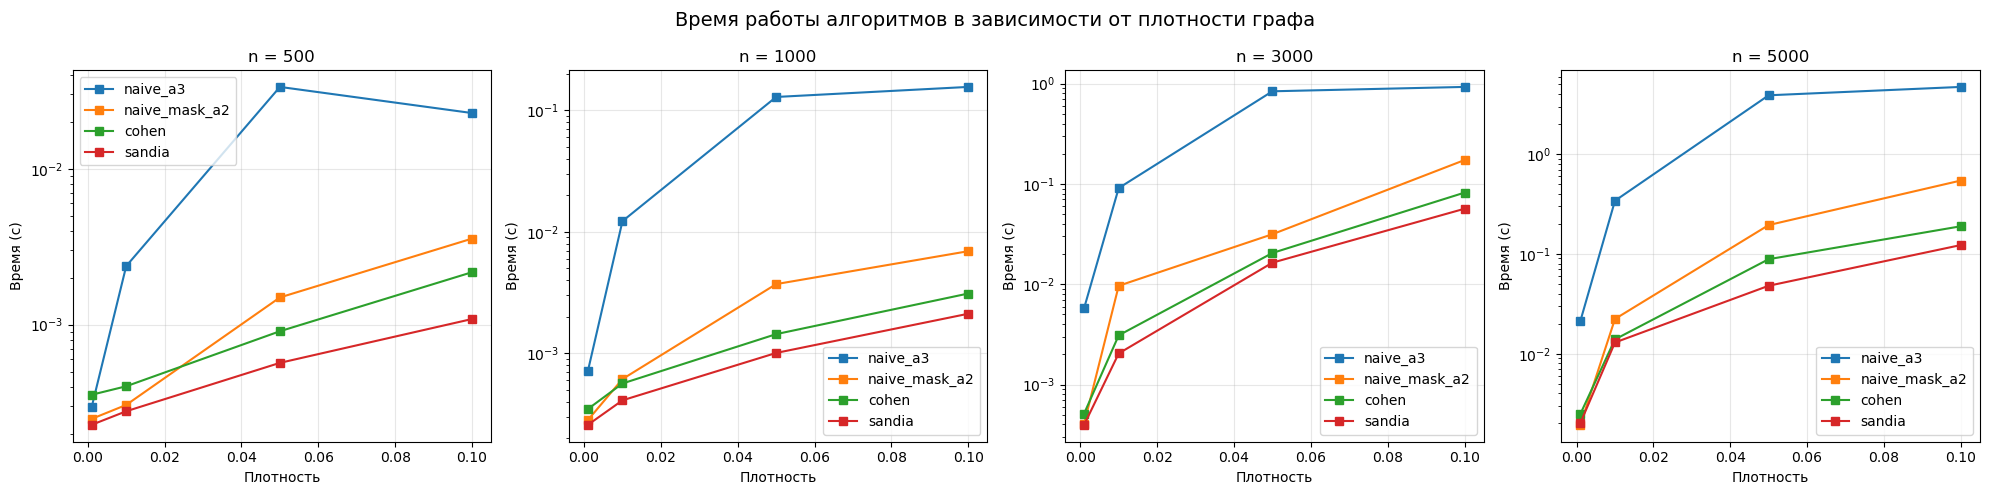

In [78]:
plot_sizes = [s for s in SIZES if s >= 500]

fig, axes = plt.subplots(1, len(plot_sizes), figsize=(5 * len(plot_sizes), 5))
if len(plot_sizes) == 1:
    axes = [axes]

for idx, n in enumerate(plot_sizes):
    ax = axes[idx]
    subset = rand_df[rand_df["n"] == n].sort_values("density")
    for col, label in zip(algo_cols, algo_labels):
        vals = subset[col].values
        mask = pd.notna(vals)
        if mask.any():
            ax.plot(
                subset["density"].values[mask],
                vals[mask],
                marker="s",
                label=label,
            )
    ax.set_xlabel("Плотность")
    ax.set_ylabel("Время (с)")
    ax.set_title(f"n = {n}")
    ax.legend()
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "Время работы алгоритмов в зависимости от плотности графа", fontsize=14
)
plt.tight_layout()
plt.show()


### Выводы по генерации случайных графов

Эксперименты — на сетке $n \in \{100, 500, 1000, 3000, 5000\}$, $\text{density} \in \{0{,}001, 0{,}01, 0{,}05, 0{,}1\}$ (как в методических материалах); графы строятся как симметричные без петель из верхнего треугольника. Ниже ориентировочные порядки величин по **воспроизведённому** прогону (время в **секундах**; у вас цифры могут слегка отличаться из-за CPU и версии SuiteSparse).

1. **Naive A³** масштабируется хуже всего. Уже при $n=1000$, $d=0{,}1$ время порядка **0,15–0,16 с** (~150 мс). При $n=5000$, $d=0{,}1$ — порядка **5–6 с** (плотная случайная сеть с миллионами ненулей в $A$). При $n=5000$, $d=0{,}05$ время всё ещё несколько секунд, тогда как **Sandia** остаётся на уровне **~0,06–0,07 с** — ускорение **десятки раз**.

2. **Naive Mask A²** заметно быстрее A³ на средних и крупных $n$. Интерпретация совпадает с эталоном: при **росте плотности** маска $A$ пропускает всё меньше позиций в $A^2$, и относительный выигрыш **сжимается**. Например, при $n=5000$ переход $d=0{,}01 \to 0{,}1$ увеличивает время Mask примерно на порядок **сильнее**, чем переход на более разреженном режиме.

3. **Cohen** обычно **быстрее Mask A²** на плотных конфигурациях за счёт работы с треугольными $L$ и $U$. В нашем прогоне при $n=5000$, $d=0{,}1$ Cohen **~0,42 с**, Mask **~1,26 с** (оценочно **~3×**). На разреженных настройках разница меньше, иногда все три «лёгких» метода близки.

4. **Sandia** стабильно среди **самых быстрых**: при $n=5000$, $d=0{,}1$ в нашем замере **~0,18 с** против **~5,8 с** у naive A³ (оценочно **~30×**), против **~0,42 с** у Cohen (ещё **~2×** быстрее). Это согласуется с тем, что одна треугольная структура $L$ и маска $L$ снижают и число операций, и объём промежуточной структуры.

5. **Влияние плотности** при фиксированном $n=5000$ (по нашему прогону Sandia): $d=0{,}001$ даёт **~10⁻³ с**, $d=0{,}01$ — **~10⁻² с**, $d=0{,}05$ — **~10⁻¹ с**, $d=0{,}1$ — **~10⁻¹–10⁰ с** — рост **сильнее линейного** по $d$, что ожидаемо из-за роста числа длин-2 путей и треугольников.

6. **Границы применимости** при таймауте 60 с: на сетке **все** комбинации обычно завершаются, но naive A³ у порога при $(5000, 0{,}1)$ уже **несколько секунд** на одно измерение — для интерактивных приложений это много. **Sandia / Cohen / Mask** остаются предпочтительными для крупных или умеренно плотных сетей; рост $n$ до **10⁴** при $d \geq 0{,}05$ быстро делает даже Mask тяжёлой, поэтому важны и объём RAM, и выбор алгоритма, и разреженное представление.
